In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Node, Material,
    # Sections
    Membrane,
    # Elements
    CST, LST, Quad4, Quad9,
    # Gmsh tools
    read_mesh, build_nodes, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average, plot_gmsh_mesh,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d ,
    # Units
    mm, cm, m, kgf, N, tf, kN, MPa, GPa, kg,
    # Parameters
    globalParameters,
)

# Standard libraries
import os
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 0.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'batman'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [6]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                19:   {'value': 100, 'direction': 'x'},   
                20:   {'value': 100, 'direction': '-x'},   

}

In [7]:
# Read raw mesh data from gmsh file
mesh = read_mesh(output_file)

# Instantiate Node objects and apply boundary conditions
node_map, nodes, system_nDof = build_nodes(mesh, restrain_dictionary)

  MESH SUMMARY

  === NODES ===  (2681 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        -1.0000         1.0000         0.0000
       2        -0.7500         3.0000         0.0000
       3        -0.5000         2.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      18      0   'support'
      19      1   'load_p_x'
      20      1   'load_m_x'
      17      2   'steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      18      0       15          1            2   'su

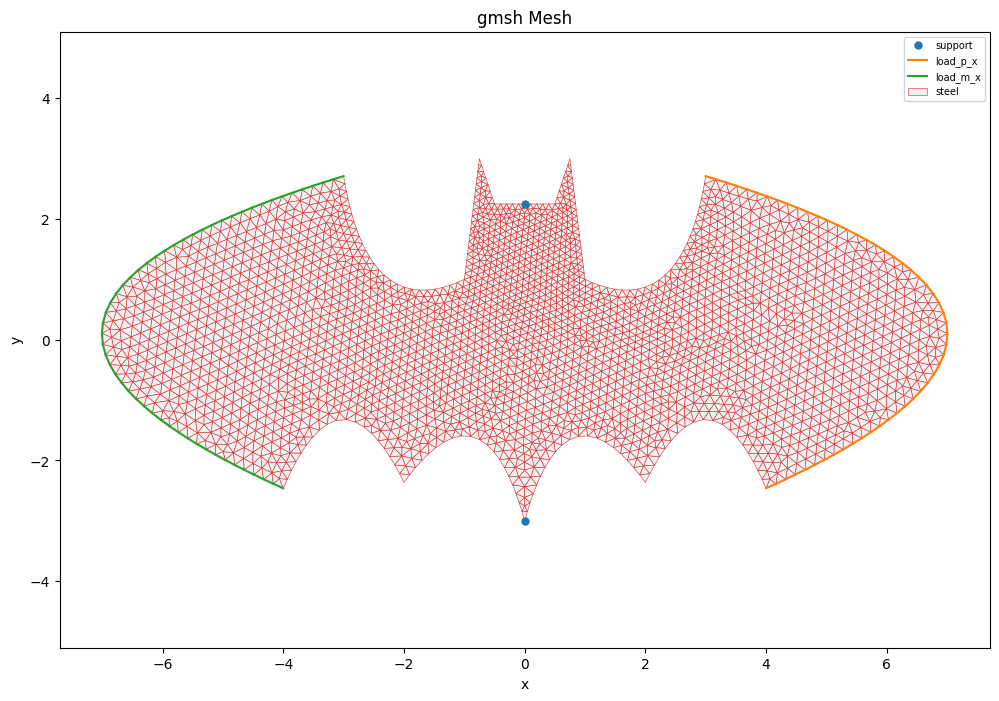

In [8]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [9]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Instantiate FEM element objects from mesh connectivity
elements = build_elements(  mesh=mesh,
                            node_map=node_map,
                            section_dictionary=section_dictionary,
                            element_class_map=element_map )

In [10]:
# Build global nodal force vector from load dictionary
F_load = build_load_vector(mesh=mesh, 
                            node_map=node_map, 
                            load_dictionary=load_dictionary)

In [11]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodes:
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodes])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Remove load on restrained DOFs (they go to reactions directly)
F[restrained_dofs] = 0.0

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [12]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [13]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [-0.5   2.25]:  ux=+0.001014  uy=+0.108405
Node 268 at [6.864838 0.614433]:  ux=+0.096895  uy=-0.098633


In [14]:
# Reactions per node
for node in nodes:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 4:  Rx=-0.000000  Ry=+0.000000
Node 9:  Rx=+0.000000  Ry=+0.000000
----------------------------------------------------------------------------------------------------
Applied X:  -0.0000   Reaction X: -0.0000   Balance: -1.3767e-10
Applied Y:  +0.0000   Reaction Y: +0.0000   Balance: 1.1187e-13


In [15]:
for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 11 at [-4.       -2.461955]:  Fx=-8.9578  Fy=+0.0000
Node 12 at [ 4.       -2.461955]:  Fx=+8.9578  Fy=+0.0000
Node 13 at [-3.        2.710524]:  Fx=-8.9578  Fy=+0.0000
Node 14 at [3.       2.710524]:  Fx=+8.9578  Fy=+0.0000
Node 119 at [-3.171265  2.657935]:  Fx=-17.9155  Fy=+0.0000
Node 120 at [-3.342141  2.604105]:  Fx=-17.9156  Fy=+0.0000
Node 121 at [-3.512599  2.548956]:  Fx=-17.9155  Fy=+0.0000
Node 122 at [-3.682593  2.492408]:  Fx=-17.9154  Fy=+0.0000
Node 123 at [-3.852086  2.434365]:  Fx=-17.9155  Fy=+0.0000
Node 124 at [-4.021023  2.374727]:  Fx=-17.9156  Fy=+0.0000
Node 125 at [-4.189349  2.31338 ]:  Fx=-17.9156  Fy=+0.0000
Node 126 at [-4.356992  2.250196]:  Fx=-17.9154  Fy=+0.0000
Node 127 at [-4.523875  2.185035]:  Fx=-17.9154  Fy=+0.0000
Node 128 at [-4.689908  2.117731]:  Fx=-17.9155  Fy=+0.0000
Node 129 at [-4.854978  2.048104]:  Fx=-17.9154  Fy=+0.0000
Node 130 at [-5.018956  1.975943]:  Fx=-17.9154  Fy=+0.0000
Node 131 at [-5.181685  1.901008]:  Fx=-17.9153  F

In [16]:
# Check if any restrained node has load
for node in nodes:
    if any(r == 'r' for r in node.restrain):
        fy = F_load[node.idx[1]]
        if abs(fy) > 0:
            print(f"Node {node.name} at {node.coordinates}: restrained but has Fy={fy:+.4f}")

In [17]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    u_3d[i, 0] = u[node.idx[0]]  # Displacement in X
    u_3d[i, 1] = u[node.idx[1]]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    F_3d[i, 0] = F[node.idx[0]]  # Force in X
    F_3d[i, 1] = F[node.idx[1]]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    R_3d[i, 0] = R[node.idx[0]]  # Reaction in X
    R_3d[i, 1] = R[node.idx[1]]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [18]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

2

In [19]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [20]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [21]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [22]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

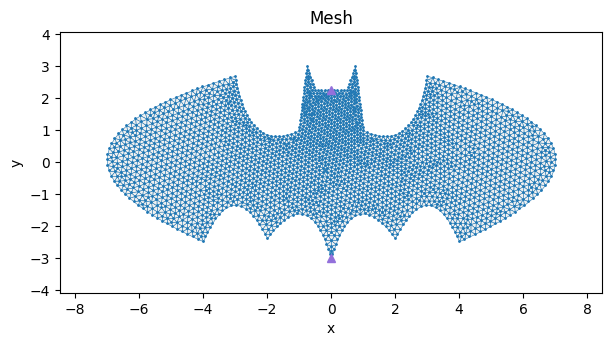

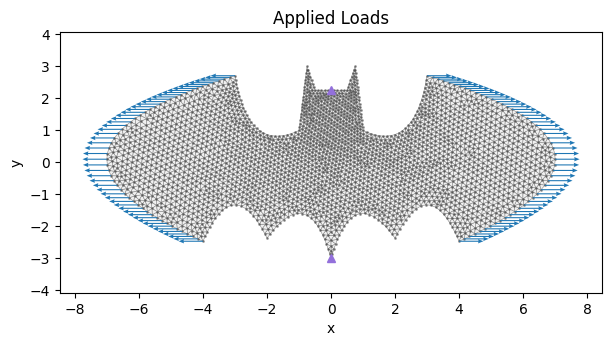

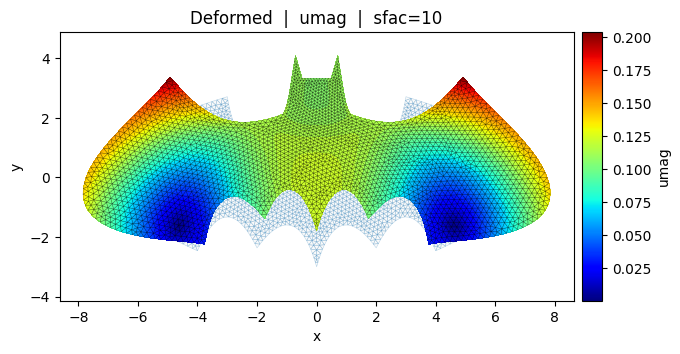

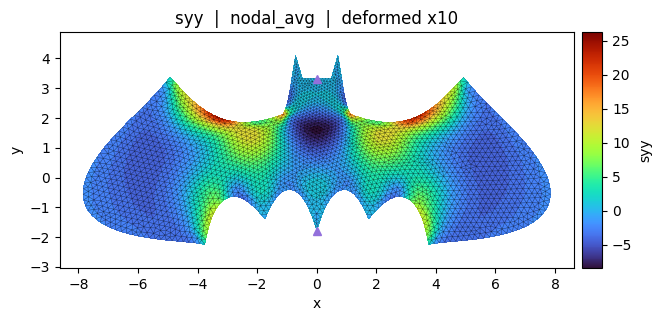

In [23]:
# Mesh
plot_mesh(
    nodes               = nodes,
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (7, 7),
    # view_3d            = True,   elev= 45, azim= -45,
    ax                  = None,
    save                = None,   
)


# Loads
plot_loads_2d (
    nodes    = nodes,
    elements = elements,
    F_load   = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize  = (7, 7),
    # view_3d            = True,   elev= 45, azim= -45,
    ax       = None,
    save     = None,    
)

# Deformed
plot_deformed(
    nodes     = nodes,
    elements  = elements,
    u         = u,
    component = 'umag',   # 'ux', 'uy', 'umag'
    sfac      = 10,
    cmap      = 'jet',
    limit               = None,      
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = False,
    figsize             = (7, 7),
    # view_3d            = True,   elev= 45, azim= -45,
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d (
    nodes       = nodes,
    elements    = elements,
    u           = u,
    component   = 'syy',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed    = True,
    sfac        = 10,
    limit       = None,         # e.g. (-250, 250) highlights elements outside range in red
    # levels      = 20,
    cmap        = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (7, 7),
    # view_3d            = True,   elev= 45, azim= -45,
    ax                  = None,
    save                = None,
)